<a href="https://colab.research.google.com/github/ParamAhuja/DL_Notebooks/blob/main/CNN_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from keras.datasets import mnist
(X_train, y_train), (X_test, y_tes) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
X_train[0].shape

(28, 28)

In [ ]:
y_train.shape

(60000,)

In [ ]:
# class CNN:
#   def __init__(self):
#     pass

In [ ]:
import numpy as np
import math

In [ ]:
def relu(input: np.ndarray) -> np.ndarray:
  return np.maximum(0, input)

In [ ]:
# def Conv2D(nfilters:int, kernel_size: tuple, input_size: tuple, activation: str, weights, bias, stride_size = (1,1)) -> tuple:
#   # assuming gray
#   # assuming no padding
#   # assuming default stride
#   # assuming single image at a time

#   output_size = (input_size[0] - stride_size[0] + 1, kernel_size[1] - kernel_size[1] + 1, nfilters )

#   for i in range(nfilters):
#     for j in range(output_size[0], output_size[1]):




#   return (0,)

In [ ]:
def MaxPooling2D(input: np.ndarray, pool_size = (2,2) , stride_size = (2,2), padding = "valid") -> np.ndarray:

  input_height, input_width = input.shape
  pool_height, pool_width = pool_size
  stride_height, stride_width = stride_size

  padded_input = input

  if padding == "valid":
    a = math.floor((input_height - pool_height) / stride_height) + 1
    b = math.floor((input_width - pool_width) / stride_width) + 1
    pad_h_before, pad_h_after = 0, 0
    pad_w_before, pad_w_after = 0, 0

  elif padding == "same":
    a = math.ceil(input_height / stride_height)
    b = math.ceil(input_width / stride_width)

    total_pad_height = (a - 1) * stride_height + pool_height - input_height
    total_pad_width = (b - 1) * stride_width + pool_width - input_width

    pad_h_before = total_pad_height // 2
    pad_h_after = total_pad_height - pad_h_before
    pad_w_before = total_pad_width // 2
    pad_w_after = total_pad_width - pad_w_before

    padded_input = np.pad(input,
                          ((pad_h_before, pad_h_after), (pad_w_before, pad_w_after)),
                          mode='constant',
                          constant_values=0)
  else:
    raise ValueError("Padding must be 'valid' or 'same'.")

  if a <= 0 or b <= 0:
      raise ValueError("Pooling parameters result in an invalid output size. "
                       "Please check input dimensions, pool_size, and stride_size.")


  output = np.zeros((a, b))

  for j in range(0, b):
    for i in range(0, a):

      h_start = i * stride_height
      w_start = j * stride_width
      h_end = h_start + pool_height
      w_end = w_start + pool_width
      pool = padded_input[h_start:h_end, w_start:w_end]

      # flatten and take max
      # flattened = pool.reshape(1, -1)[0]
      # output[i][j] = max(flattened)
      output[i][j] = np.max(pool)

  return output

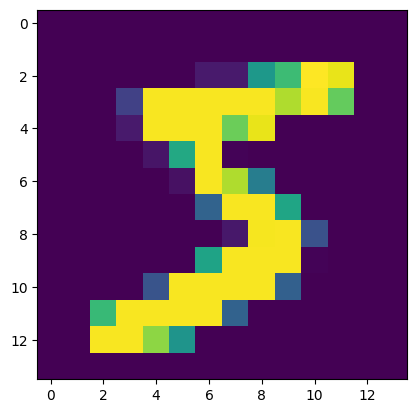

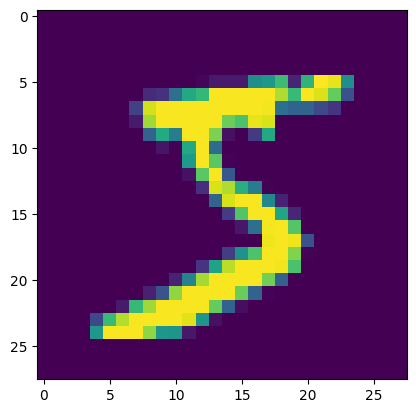

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(MaxPooling2D(X_train[0]))
plt.show()
plt.imshow(X_train[0])
plt.show()

In [ ]:
def flatten(input: np.ndarray) -> np.ndarray:
  return input.flatten()